# UHI Modelling V2

I am attempting a revised workflow for modelling UHI.
First, the model is now going to include weather variables obtained from OpenMeteo. The data will then be aggregated with the Landsat data and used to build the model with the workflow below:  
1. Identify the world's climates from an authority (like the Trewartha climate classification).
2. Get substantial satellite (which will eventually include those those climate categories) and weather data on countries in those regions across the months (seasons) in a particular year.
3. Train a model on the data, implementing train-validation-test split, and predict UHI intensity on the test set.
4. Group the test examples by climate and compute the RMSE scores across the climates.
5. Cluster the UHI features to identify the types and categories of UHI.
6. Then I, human, assess the errors and prediction accuracies across each manufactured UHI cluster and how they vary across climates.

***"This project predicts urban heat island intensity using satellite and environmental data and evaluates how prediction reliability and errors vary across global climates and urban thermal types."***

## Testing aggregation with minimal data

To test the flow of data:  
1. From the various countries
2. In the various climates
3. Once a week from Jan 1 2025 to Dec 31 2025
4. From Earth Engine (Landsat) and OpenMeteo

I will be using as minimal data as possible. This will look like:  
1. Lagos, Ontario, Helsinki, and Tehran
2. Aw, Dc, Dcb, Bsk
3. Once a month Jan 1 2025 to Dec 31 2025
4. From Earth Engine and OpenMeteo

## Fetching from Open-Meteo

Again, the cities I want to sample are:
1. Lagos, Nigeria
2. Ontario, Canada
3. Tehran, Iran
4. Helsinki, Finland

The variables I am getting from Open-meteo are:
1. Cloud Cover (Low)
2. Air Temperature (2m)
3. Ralative Humidity
4. Precipitation
5. Wind Speed (10m)

In [2]:
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

In [3]:
from spectral import get_spectral, get_viirs

cities = [
    {"code": "CAN", "name": "Ontario"},
    {"code": "IRN", "name": "Tehran"},
    {"code": "NGA", "name": "Lagos"},
	{"code": "FIN", "name": "Uusimaa"},
]

date_range = ("2025-01-01", "2025-12-31")

for city in cities:
    get_spectral(city['code'], city['name'], date_range)
    get_viirs(city['code'], date_range)


c:\Software Projects\Data Projects\uhi-modelling\uhenv\Lib\site-packages\geemap\conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sample points already exist at data/CAN_sample_points.csv.

VIIRS data already exists at data/CAN_viirs_features.csv.

Sample points already exist at data/IRN_sample_points.csv.

VIIRS data already exists at data/IRN_viirs_features.csv.

Sample points already exist at data/NGA_sample_points.csv.

VIIRS data already exists at data/NGA_viirs_features.csv.

Sample points already exist at data/FIN_sample_points.csv.

VIIRS data already exists at data/FIN_viirs_features.csv.



In [4]:
import pandas as pd

for city in cities:
    df = pd.read_csv(f"data/{city['code']}_sample_points.csv")
    urban = (df["LandCover"] == 50).sum()
    rural = (df["LandCover"] != 50).sum()
    print(f"{city['name']}: {urban} urban, {rural} rural, total: {len(df)}")

Ontario: 100 urban, 100 rural, total: 200
Tehran: 100 urban, 100 rural, total: 200
Lagos: 100 urban, 100 rural, total: 200
Uusimaa: 100 urban, 100 rural, total: 200


In [5]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    print(f"{city['name']}: {len(df)} rows")
    print(df[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

Ontario: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Tehran: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Lagos: 2229 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Uusimaa: 2198 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64


In [6]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    missing_months = set(range(1, 13)) - set(df["month"].unique())
    print(f"{city['name']}: missing months {missing_months}")

Ontario: missing months set()
Tehran: missing months set()
Lagos: missing months set()
Uusimaa: missing months {6}


In [7]:
from weather import process_city_weather

for city in cities:
    process_city_weather(city['code'], date_range)

Data has already been processed at data/CAN_Full_UHI_Data.csv.

Data has already been processed at data/IRN_Full_UHI_Data.csv.

Data has already been processed at data/NGA_Full_UHI_Data.csv.

Data has already been processed at data/FIN_Full_UHI_Data.csv.



In [8]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    print(f"{city['name']}: {len(df)} rows")

Ontario: 4800 rows
Tehran: 4800 rows
Lagos: 4800 rows
Uusimaa: 4800 rows


Now that we have fetched our data, we will add the `city` column and concatenate all four datasets.

In [ ]:
# Step 1 — Consolidate all cities
viirs_dfs, weather_dfs = [], []

for city in cities:
    viirs_df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    viirs_df["city"] = city["name"]
    viirs_dfs.append(viirs_df)

    weather_df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    weather_df["city"] = city["name"]
    weather_dfs.append(weather_df)

viirs_data = pd.concat(viirs_dfs, ignore_index=True)
weather_data = pd.concat(weather_dfs, ignore_index=True)

# Step 2 — Parse date and extract month and time
weather_data["date"] = pd.to_datetime(weather_data["date"], utc=True)
weather_data["month"] = weather_data["date"].dt.month
weather_data["time"] = weather_data["date"].dt.hour.map({1: "night", 13: "day"})


# Step 4 — Merge VIIRS into uhi_data on lat/lon + city + month
uhi_data = weather_data.merge(
    viirs_data,
    on=["latitude", "longitude", "city", "month"],
    how="left"
)

print(uhi_data.shape)
print(uhi_data.head())
print(uhi_data[["LandCover", "Elevation", "LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

(19200, 20)
LandCover      0
Elevation      0
LST_day      746
LST_night    746
NDVI         746
NDBI         746
MNDWI        746
SAVI         746
Albedo       746
dtype: int64


In [10]:
print(uhi_data[uhi_data["LST_day"].isnull()]["city"].value_counts())
print(uhi_data[uhi_data["LST_day"].isnull()]["month"].value_counts())

city
Uusimaa    404
Lagos      342
Name: count, dtype: int64
month
6     426
3      48
8      36
7      30
12     28
4      28
9      28
2      26
10     26
5      26
11     26
1      18
Name: count, dtype: int64


In [11]:
uhi_data = uhi_data.sort_values(["city", "latitude", "longitude", "month", "time"]).reset_index(drop=True)

for col in ["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]:
    uhi_data[col] = uhi_data.groupby(["city", "latitude", "longitude"])[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print(uhi_data[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

LST_day      192
LST_night    192
NDVI         192
NDBI         192
MNDWI        192
SAVI         192
Albedo       192
dtype: int64


In [12]:
null_mask = uhi_data["LST_day"].isnull()
print(uhi_data[null_mask]["city"].value_counts())
print(uhi_data[null_mask].groupby(["city", "latitude", "longitude"])["month"].apply(list))

city
Lagos    192
Name: count, dtype: int64
city   latitude  longitude
Lagos  6.478715  3.496877     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.479197  3.438773     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.497516  3.556839     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.503954  3.539145     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.512168  3.415794     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.515417  3.518704     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.517941  3.572257     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.577391  3.676986     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
Name: month, dtype: object


In [13]:
null_pixels = uhi_data[uhi_data["LST_day"].isnull()][["city", "latitude", "longitude"]].drop_duplicates()

uhi_data = uhi_data.merge(
    null_pixels.assign(drop=True),
    on=["city", "latitude", "longitude"],
    how="left"
)
uhi_data = uhi_data[uhi_data["drop"].isnull()].drop(columns=["drop"])

print(uhi_data.shape)
print(uhi_data[["LST_day", "LST_night"]].isnull().sum())
print(uhi_data["city"].value_counts())

(19008, 20)
LST_day      0
LST_night    0
dtype: int64
city
Ontario    4800
Tehran     4800
Uusimaa    4800
Lagos      4608
Name: count, dtype: int64


In [14]:
lagos = uhi_data[uhi_data["city"] == "Lagos"]
print(lagos[["latitude", "longitude", "LandCover"]].drop_duplicates()["LandCover"].value_counts())
print(f"Urban: {(lagos['LandCover'] == 50).sum() // 24}")
print(f"Rural: {(lagos['LandCover'] != 50).sum() // 24}")

LandCover
50.0    100
10.0     40
80.0     23
30.0     14
90.0      7
20.0      5
40.0      1
60.0      1
95.0      1
Name: count, dtype: int64
Urban: 100
Rural: 92


## Rest of the workflow.

In [15]:
uhi_data["is_urban"] = (uhi_data["LandCover"] == 50).astype(int)

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")

uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

print(uhi_intensity.shape)
print(uhi_intensity[["SUHI_day", "SUHI_night", "AUHI"]].describe())
print(uhi_intensity[["n_urban", "n_rural"]].value_counts())

(96, 8)
        SUHI_day  SUHI_night       AUHI
count  96.000000   96.000000  96.000000
mean    0.064075    0.040410   1.245613
std     0.072681    0.037440   1.958347
min    -0.058016   -0.008752  -3.187605
25%     0.014779    0.006326  -0.089142
50%     0.062932    0.027761   0.381726
75%     0.120517    0.081922   3.198875
max     0.210861    0.093826   7.611895
n_urban  n_rural
100      100        72
         92         24
Name: count, dtype: int64


# EDA

In [16]:
print(uhi_data.shape)
print(uhi_data.dtypes)
print(uhi_data.isnull().sum())
print(uhi_data.describe())

(19008, 21)
date               datetime64[ns, UTC]
humidity                       float64
precipitation                  float64
wind_speed                     float64
cloud_cover_low                float64
air_temperature                float64
latitude                       float64
longitude                      float64
LandCover                      float64
Elevation                      float64
city                            object
month                            int32
time                            object
Albedo                         float64
LST_day                        float64
LST_night                      float64
MNDWI                          float64
NDBI                           float64
NDVI                           float64
SAVI                           float64
is_urban                         int64
dtype: object
date               0
humidity           0
precipitation      0
wind_speed         0
cloud_cover_low    0
air_temperature    0
latitude           0
longitud

In [17]:
# 300K / 0.02 = 15000 — so raw values should be around 13000-16000
# Our values are 5-7, meaning raw values were ~250-350 (already in Kelvin in GEE)
print(uhi_data[["LST_day", "LST_night"]].describe())
print(uhi_data["LST_day"].mean() / 0.02)  # what the value should have been

            LST_day     LST_night
count  19008.000000  19008.000000
mean       5.932481      5.652698
std        0.328607      0.260875
min        5.147400      4.967015
25%        5.701567      5.429552
50%        5.981480      5.654038
75%        6.186600      5.909170
max        7.238000      6.208640
296.62403187658475


In [18]:
uhi_data["LST_day"] = uhi_data["LST_day"] / 0.02
uhi_data["LST_night"] = uhi_data["LST_night"] / 0.02

In [19]:
print(uhi_data[["LST_day", "LST_night"]].describe())

            LST_day     LST_night
count  19008.000000  19008.000000
mean     296.624032    282.634890
std       16.430366     13.043730
min      257.370000    248.350769
25%      285.078333    271.477624
50%      299.074000    282.701905
75%      309.330000    295.458500
max      361.900000    310.432000


In [20]:
urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")
uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

print(uhi_intensity[["SUHI_day", "SUHI_night", "AUHI"]].describe())

        SUHI_day  SUHI_night       AUHI
count  96.000000   96.000000  96.000000
mean    3.203753    2.020487   1.245613
std     3.634073    1.872024   1.958347
min    -2.900799   -0.437594  -3.187605
25%     0.738942    0.316279  -0.089142
50%     3.146589    1.388053   0.381726
75%     6.025868    4.096086   3.198875
max    10.543050    4.691322   7.611895


C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\2815354724.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(data_plot, labels=labels, patch_artist=True)


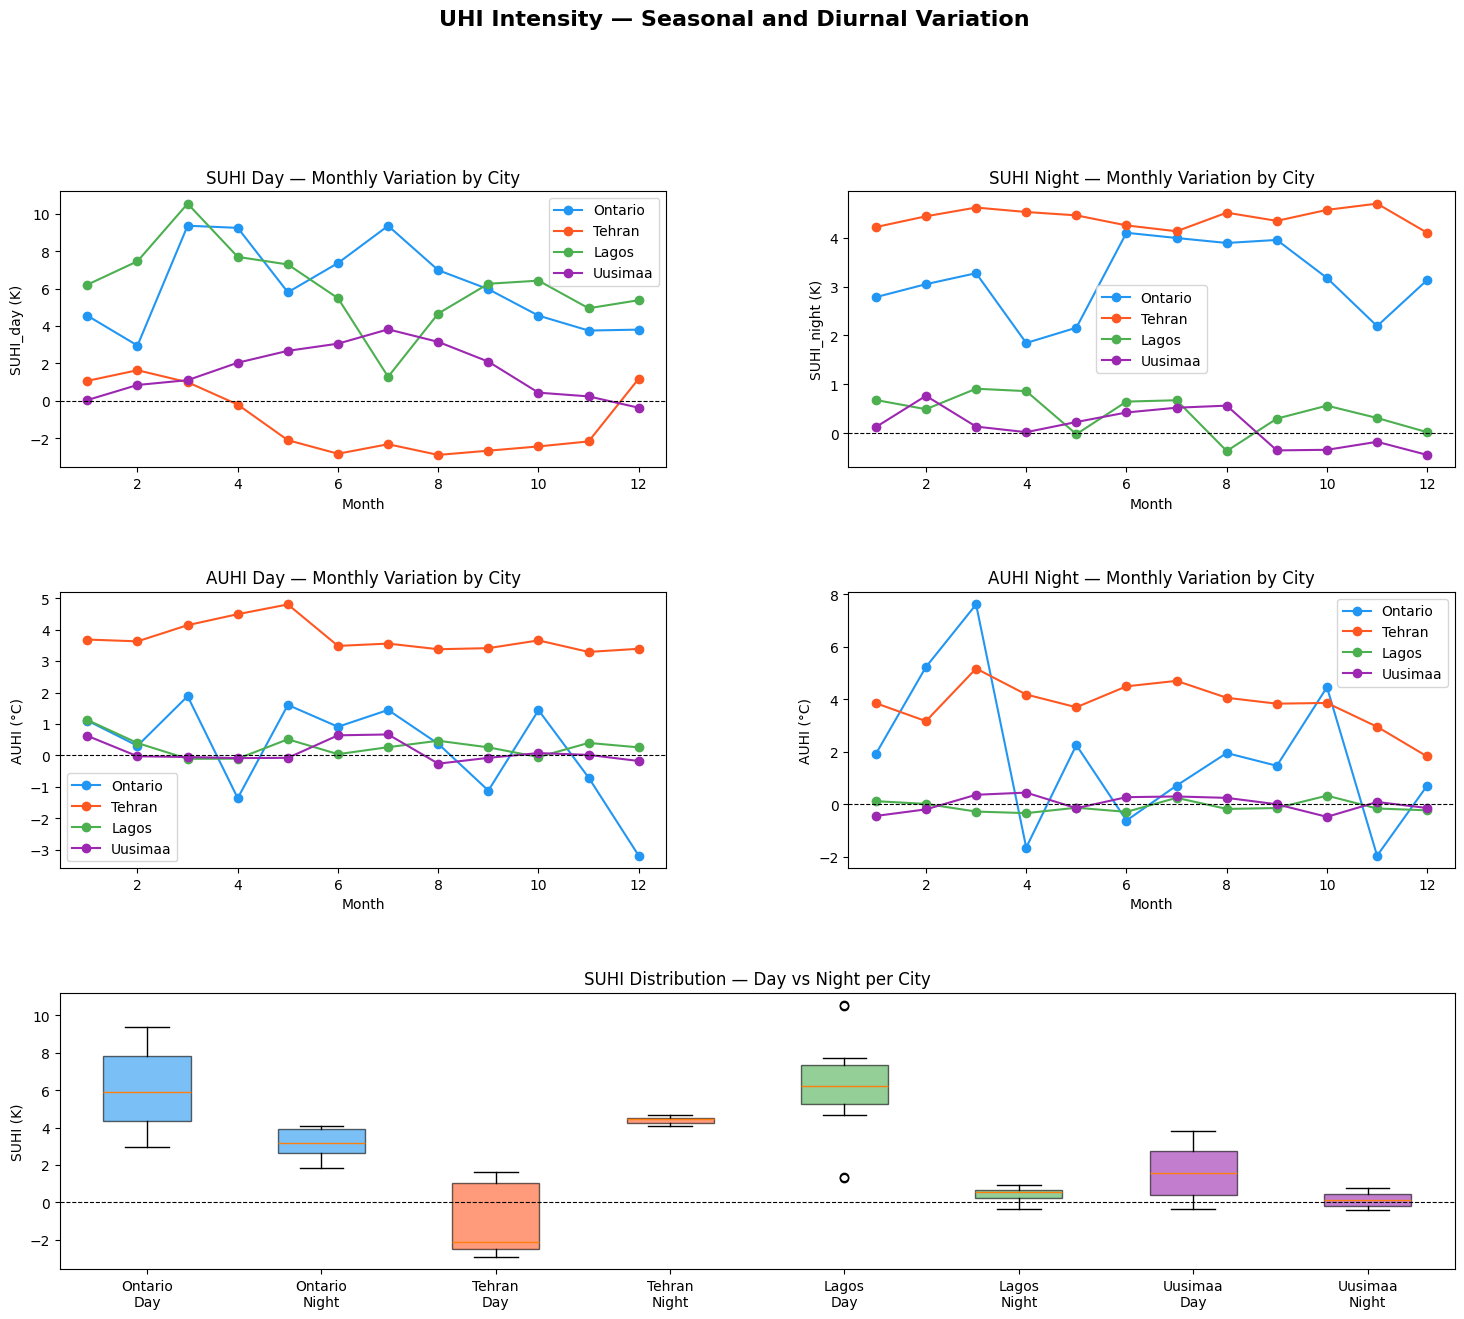

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]
times = ["day", "night"]
colors = {"Ontario": "#2196F3", "Tehran": "#FF5722", "Lagos": "#4CAF50", "Uusimaa": "#9C27B0"}

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)

# SUHI_day by city and month
ax1 = fig.add_subplot(gs[0, 0])
for city in cities:
    data = uhi_intensity[(uhi_intensity["city"] == city) & (uhi_intensity["time"] == "day")]
    ax1.plot(data["month"], data["SUHI_day"], marker="o", label=city, color=colors[city])
ax1.set_title("SUHI Day — Monthly Variation by City")
ax1.set_xlabel("Month")
ax1.set_ylabel("SUHI_day (K)")
ax1.legend()
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")

# SUHI_night by city and month
ax2 = fig.add_subplot(gs[0, 1])
for city in cities:
    data = uhi_intensity[(uhi_intensity["city"] == city) & (uhi_intensity["time"] == "night")]
    ax2.plot(data["month"], data["SUHI_night"], marker="o", label=city, color=colors[city])
ax2.set_title("SUHI Night — Monthly Variation by City")
ax2.set_xlabel("Month")
ax2.set_ylabel("SUHI_night (K)")
ax2.legend()
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")

# AUHI by city and month — day
ax3 = fig.add_subplot(gs[1, 0])
for city in cities:
    data = uhi_intensity[(uhi_intensity["city"] == city) & (uhi_intensity["time"] == "day")]
    ax3.plot(data["month"], data["AUHI"], marker="o", label=city, color=colors[city])
ax3.set_title("AUHI Day — Monthly Variation by City")
ax3.set_xlabel("Month")
ax3.set_ylabel("AUHI (°C)")
ax3.legend()
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")

# AUHI by city and month — night
ax4 = fig.add_subplot(gs[1, 1])
for city in cities:
    data = uhi_intensity[(uhi_intensity["city"] == city) & (uhi_intensity["time"] == "night")]
    ax4.plot(data["month"], data["AUHI"], marker="o", label=city, color=colors[city])
ax4.set_title("AUHI Night — Monthly Variation by City")
ax4.set_xlabel("Month")
ax4.set_ylabel("AUHI (°C)")
ax4.legend()
ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Day vs night SUHI comparison per city — boxplot
ax5 = fig.add_subplot(gs[2, :])
data_plot = []
labels = []
for city in cities:
    for time, col in [("Day", "SUHI_day"), ("Night", "SUHI_night")]:
        data_plot.append(uhi_intensity[uhi_intensity["city"] == city][col].values)
        labels.append(f"{city}\n{time}")

bp = ax5.boxplot(data_plot, labels=labels, patch_artist=True)
city_colors_list = []
for city in cities:
    city_colors_list.extend([colors[city], colors[city]])
for patch, color in zip(bp["boxes"], city_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax5.set_title("SUHI Distribution — Day vs Night per City")
ax5.set_ylabel("SUHI (K)")
ax5.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("UHI Intensity — Seasonal and Diurnal Variation", fontsize=16, fontweight="bold", y=1.01)
plt.savefig("plots/uhi_variation.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
print(uhi_intensity.sort_values(["city", "time", "month"]).to_string())

       city  month   time  n_urban  n_rural   SUHI_day  SUHI_night      AUHI
0     Lagos      1    day      100       92   6.206814    0.683552  1.126492
2     Lagos      2    day      100       92   7.460829    0.504271  0.394057
4     Lagos      3    day      100       92  10.543050    0.928984 -0.107986
6     Lagos      4    day      100       92   7.693824    0.882908 -0.103443
8     Lagos      5    day      100       92   7.288716   -0.019610  0.513188
10    Lagos      6    day      100       92   5.483313    0.650054  0.040275
12    Lagos      7    day      100       92   1.279126    0.651022  0.262275
14    Lagos      8    day      100       92   4.664551   -0.325409  0.466666
16    Lagos      9    day      100       92   6.256717    0.319340  0.256775
18    Lagos     10    day      100       92   6.422854    0.568262 -0.050660
20    Lagos     11    day      100       92   4.946484    0.316279  0.397623
22    Lagos     12    day      100       92   5.377758    0.025940  0.255862

In [23]:
predictors = uhi_data.groupby(["city", "month", "time"]).agg(
    NDVI=("NDVI", "mean"),
    NDBI=("NDBI", "mean"),
    MNDWI=("MNDWI", "mean"),
    SAVI=("SAVI", "mean"),
    Albedo=("Albedo", "mean"),
    LST_day=("LST_day", "mean"),
    LST_night=("LST_night", "mean"),
    humidity=("humidity", "mean"),
    precipitation=("precipitation", "mean"),
    wind_speed=("wind_speed", "mean"),
    cloud_cover_low=("cloud_cover_low", "mean"),
    air_temperature=("air_temperature", "mean"),
    Elevation=("Elevation", "mean")
).reset_index()

eda_df = uhi_intensity.merge(predictors, on=["city", "month", "time"], how="left")
print(eda_df.shape)
print(eda_df.columns.tolist())

(96, 21)
['city', 'month', 'time', 'n_urban', 'n_rural', 'SUHI_day', 'SUHI_night', 'AUHI', 'NDVI', 'NDBI', 'MNDWI', 'SAVI', 'Albedo', 'LST_day', 'LST_night', 'humidity', 'precipitation', 'wind_speed', 'cloud_cover_low', 'air_temperature', 'Elevation']


C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)


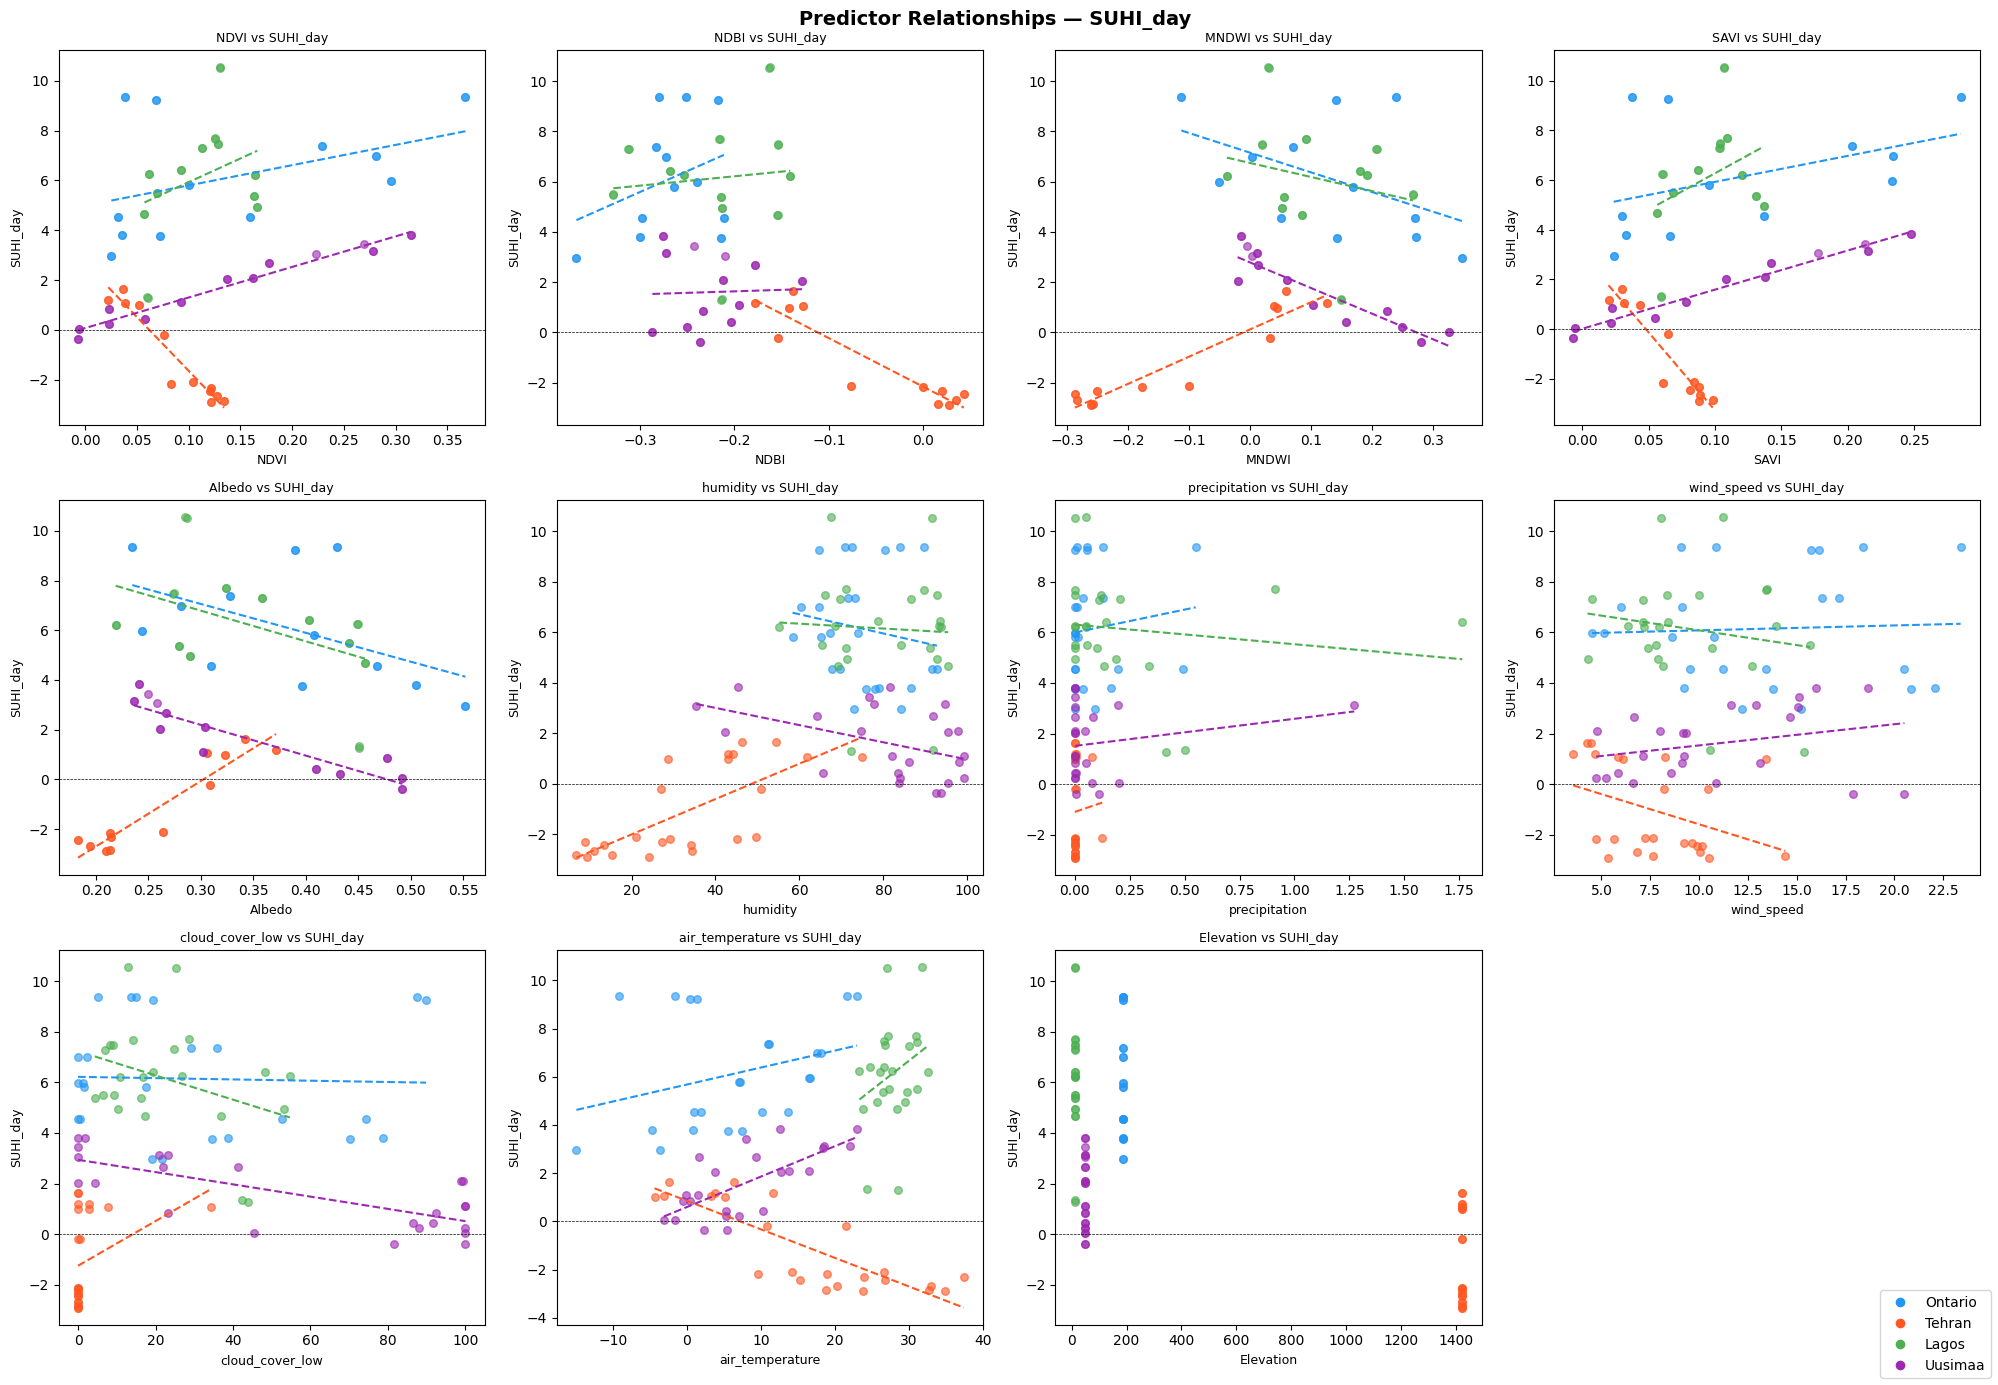

Saved plots/predictors_SUHI_day.png


C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)


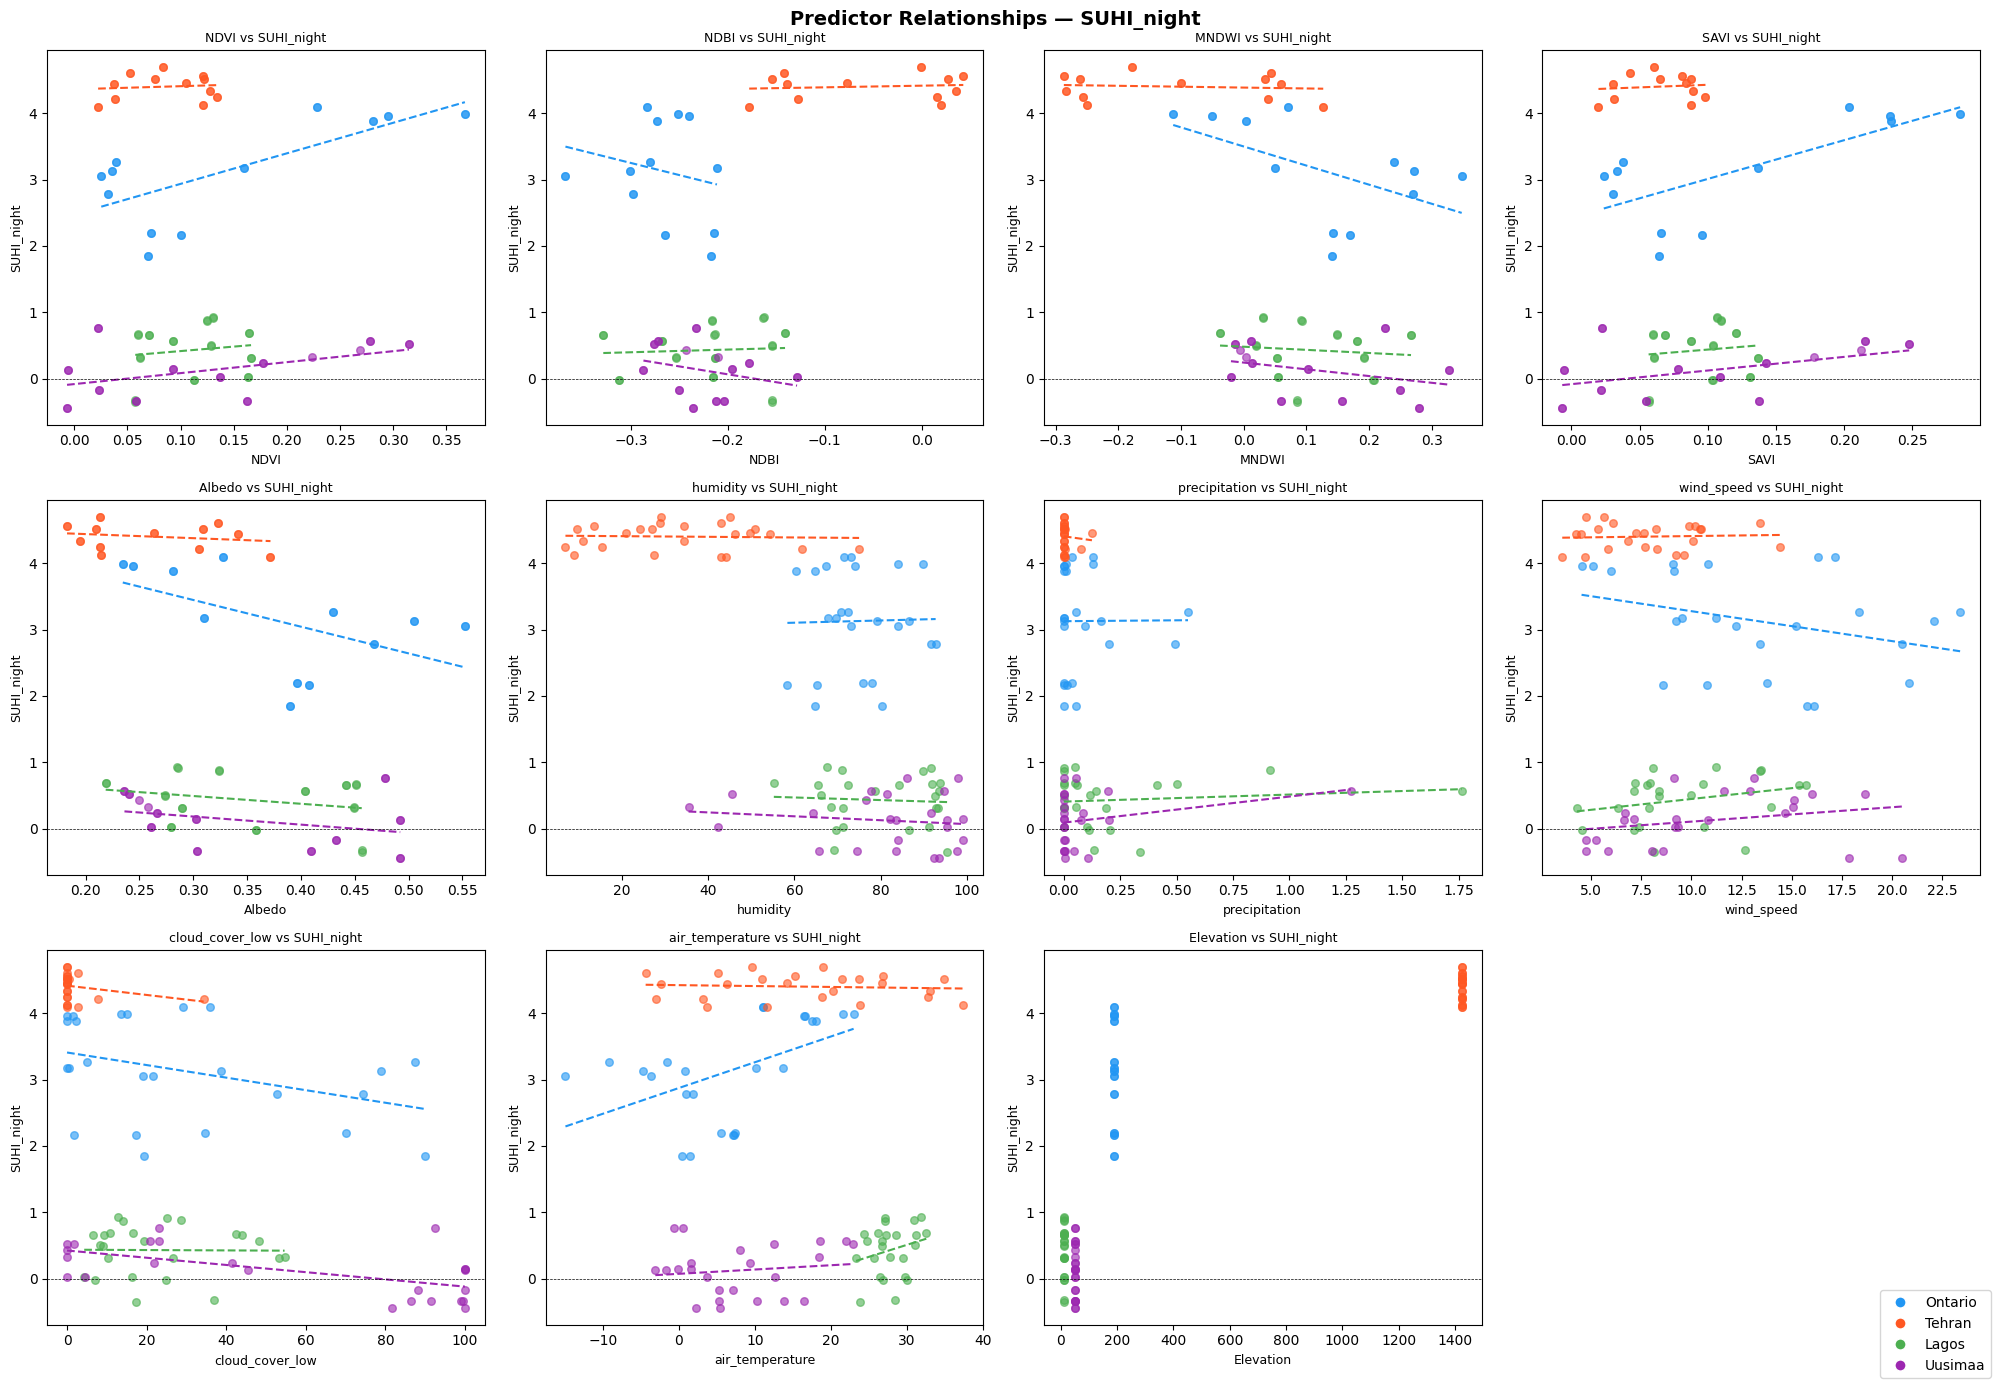

Saved plots/predictors_SUHI_night.png


C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)
C:\Users\djmck\AppData\Local\Temp\ipykernel_116684\1532703372.py:22: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(subset[predictor], subset[target], 1)


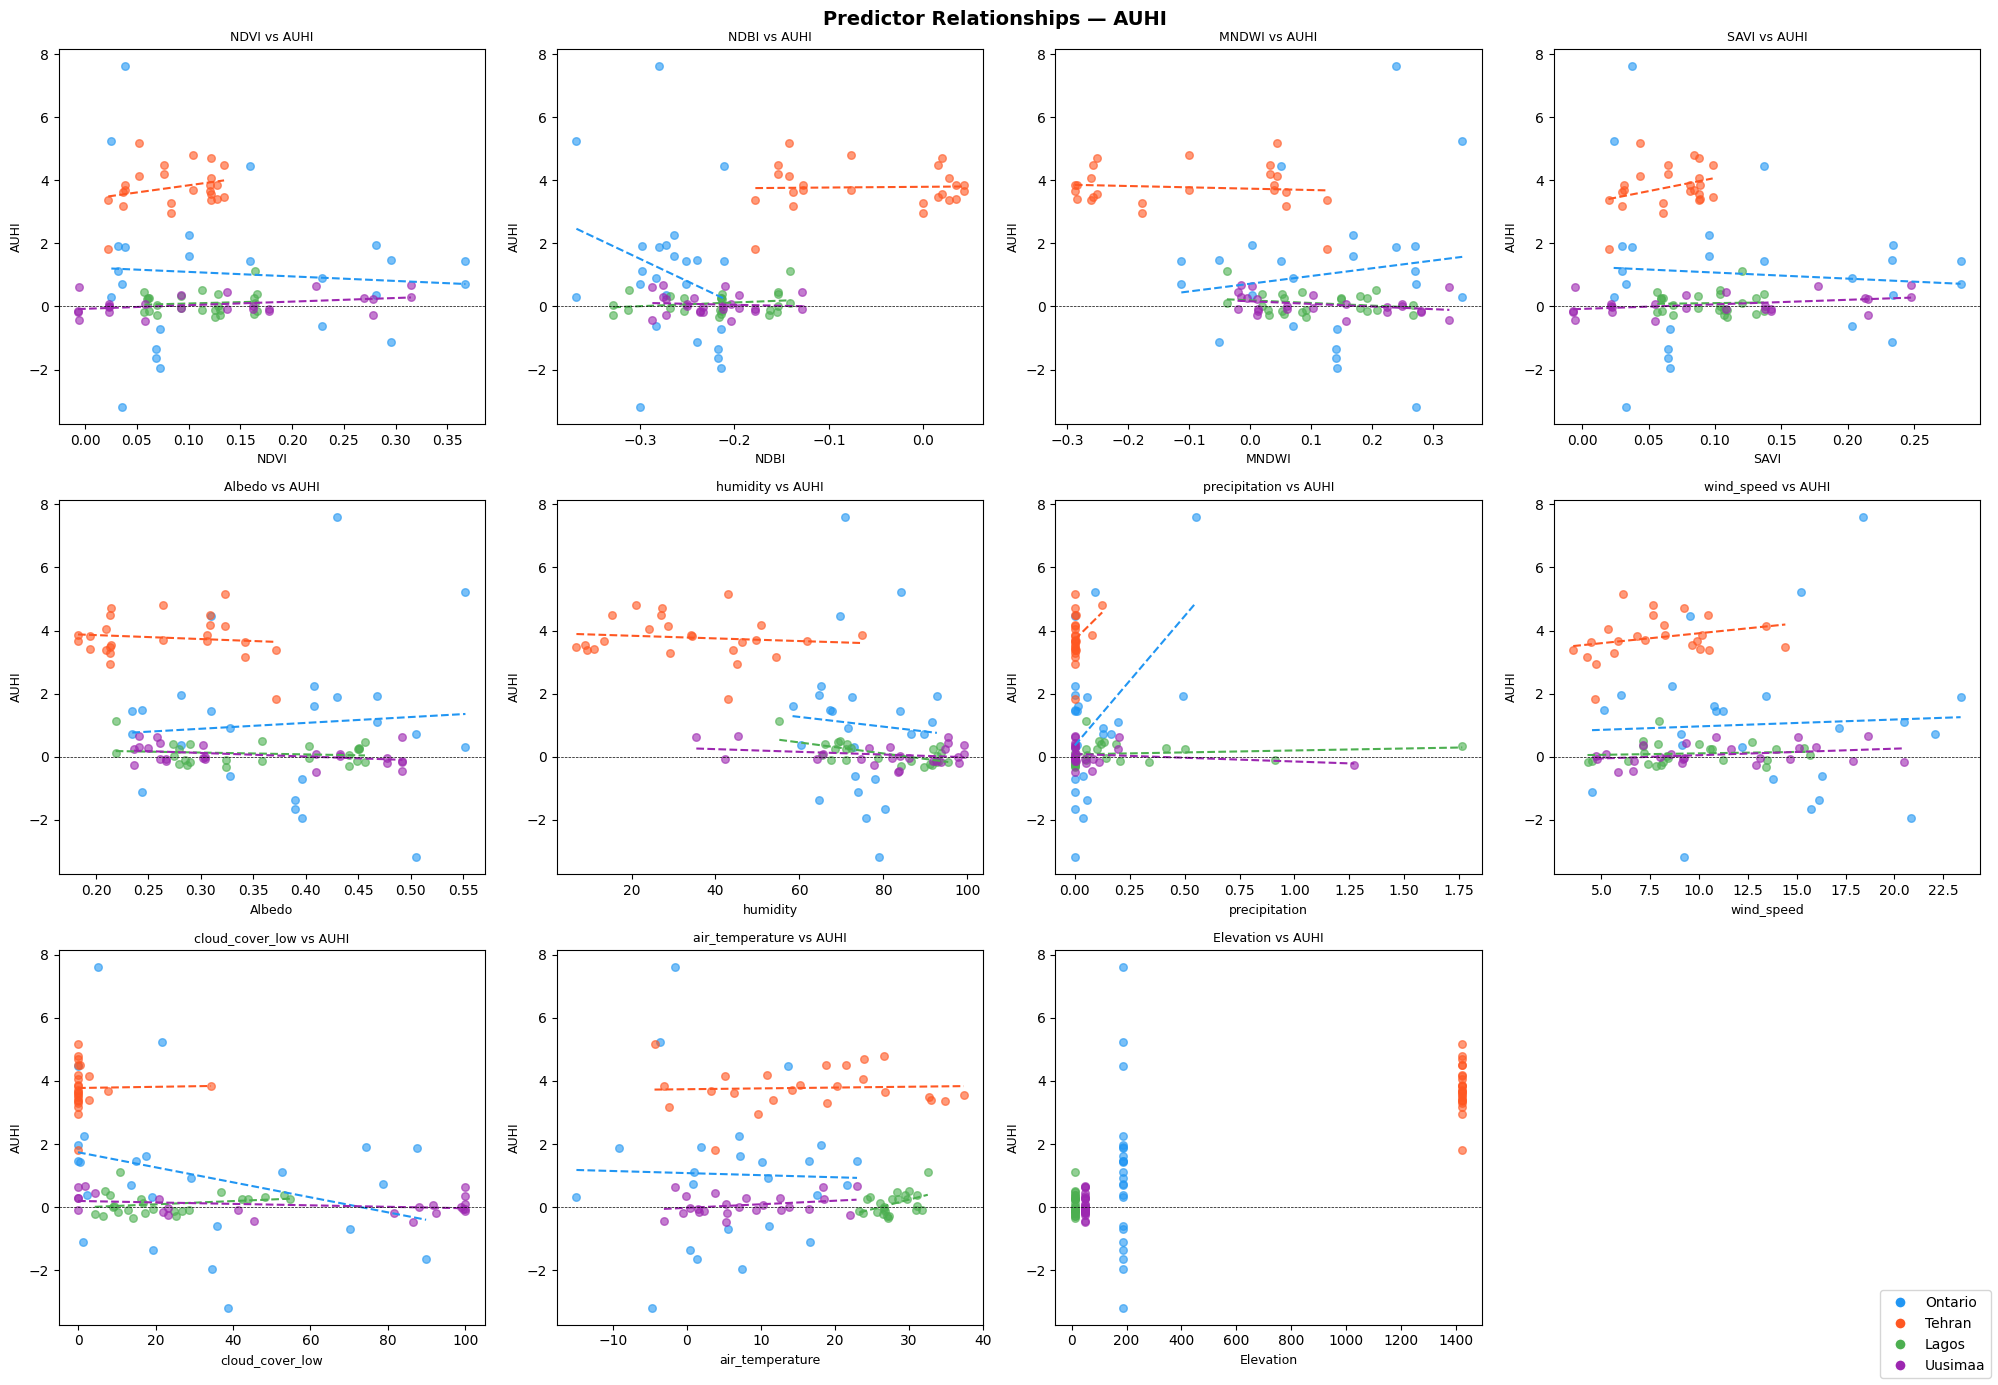

Saved plots/predictors_AUHI.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

predictors = ["NDVI", "NDBI", "MNDWI", "SAVI", "Albedo", 
              "humidity", "precipitation", "wind_speed", 
              "cloud_cover_low", "air_temperature", "Elevation"]

targets = ["SUHI_day", "SUHI_night", "AUHI"]
colors = {"Ontario": "#2196F3", "Tehran": "#FF5722", "Lagos": "#4CAF50", "Uusimaa": "#9C27B0"}

for target in targets:
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    axes = axes.flatten()
    
    for i, predictor in enumerate(predictors):
        ax = axes[i]
        for city, color in colors.items():
            subset = eda_df[eda_df["city"] == city]
            ax.scatter(subset[predictor], subset[target], 
                      color=color, alpha=0.6, s=30, label=city)
            # Add trend line per city
            z = np.polyfit(subset[predictor], subset[target], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(subset[predictor])
            ax.plot(x_sorted, p(x_sorted), color=color, linewidth=1.5, linestyle="--")
        
        ax.set_xlabel(predictor, fontsize=9)
        ax.set_ylabel(target, fontsize=9)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(f"{predictor} vs {target}", fontsize=9)

    # Hide unused subplot
    axes[-1].set_visible(False)
    
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color, markersize=8, label=city) 
               for city, color in colors.items()]
    fig.legend(handles=handles, loc="lower right", fontsize=10)
    
    fig.suptitle(f"Predictor Relationships — {target}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/predictors_{target}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plots/predictors_{target}.png")

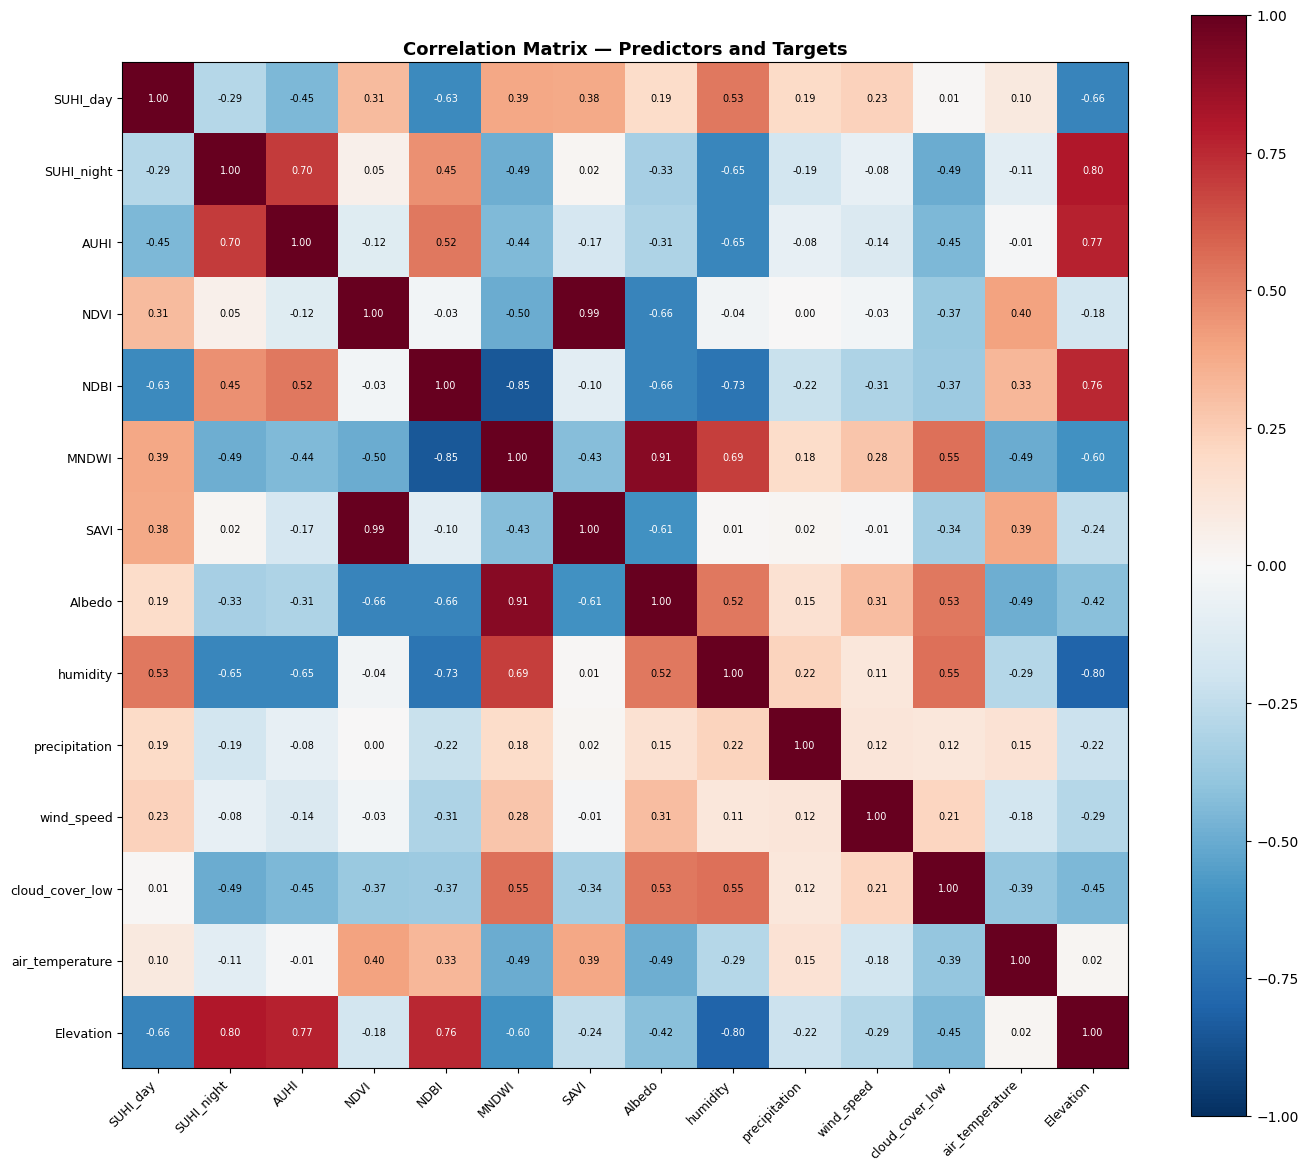

In [27]:
import matplotlib.pyplot as plt
import numpy as np

cols = ["SUHI_day", "SUHI_night", "AUHI",
        "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo",
        "humidity", "precipitation", "wind_speed",
        "cloud_cover_low", "air_temperature", "Elevation"]

corr = eda_df[cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(cols, fontsize=9)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")

ax.set_title("Correlation Matrix — Predictors and Targets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

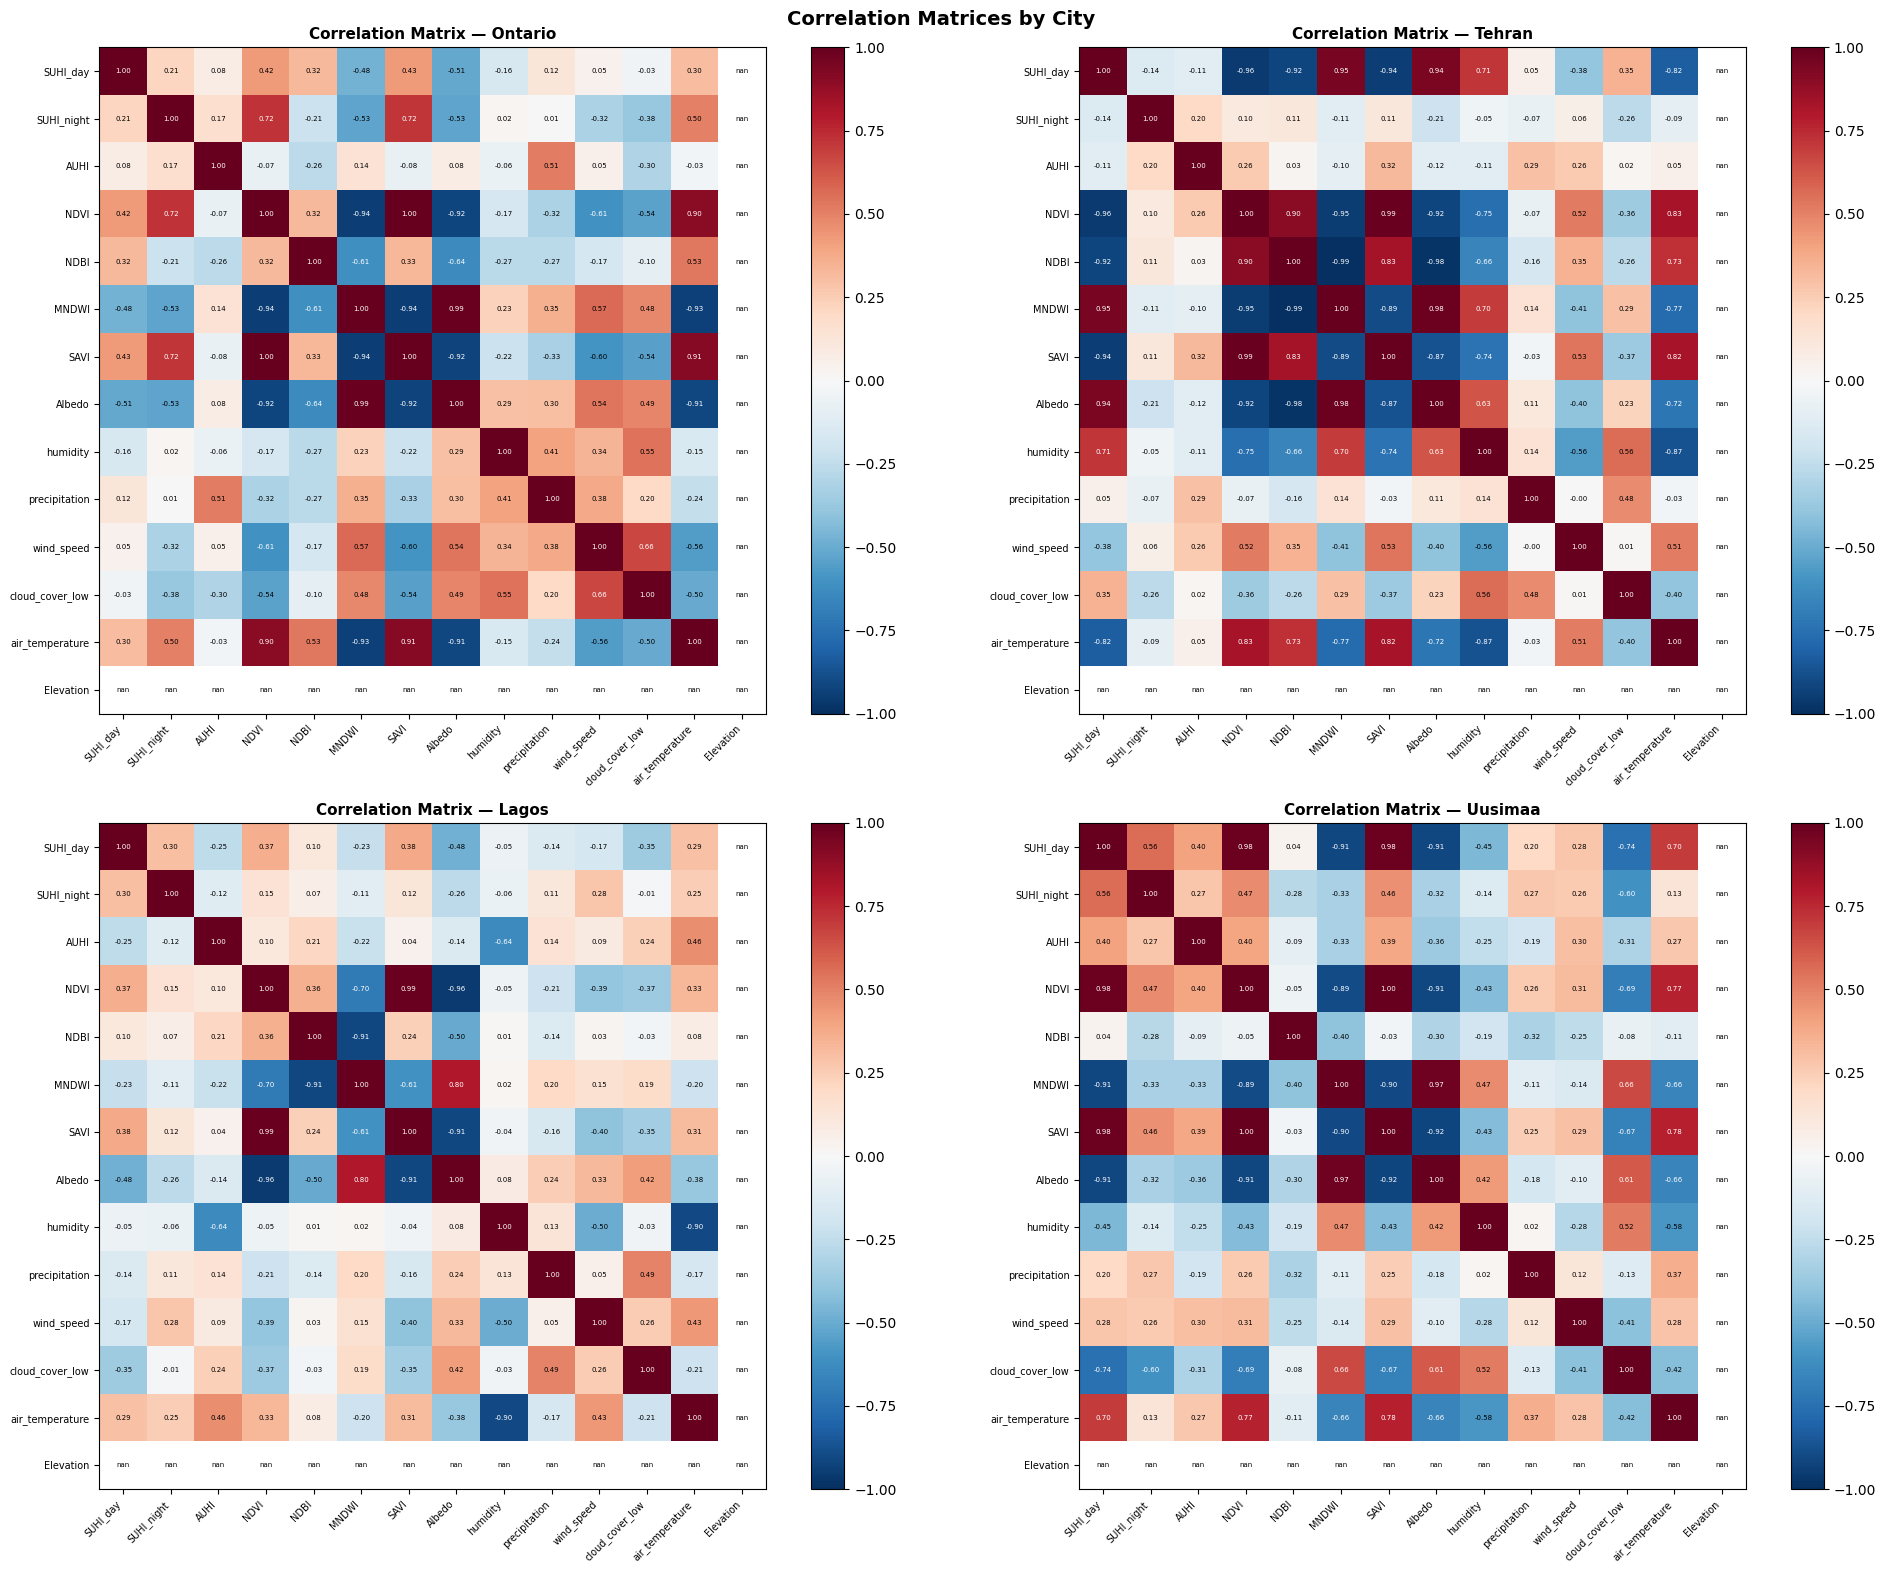

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]

for i, city in enumerate(cities):
    subset = eda_df[eda_df["city"] == city][cols]
    corr = subset.corr()
    
    ax = axes[i]
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(cols, fontsize=7)
    
    for r in range(len(cols)):
        for c in range(len(cols)):
            ax.text(c, r, f"{corr.iloc[r, c]:.2f}",
                    ha="center", va="center", fontsize=5,
                    color="white" if abs(corr.iloc[r, c]) > 0.6 else "black")
    
    ax.set_title(f"Correlation Matrix — {city}", fontsize=11, fontweight="bold")

plt.suptitle("Correlation Matrices by City", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/correlation_matrix_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
for city in ["Overall"] + ["Ontario", "Tehran", "Lagos", "Uusimaa"]:
    if city == "Overall":
        corr = eda_df[cols].corr()
    else:
        corr = eda_df[eda_df["city"] == city][cols].corr()
    
    print(f"\n{'='*20} {city} {'='*20}")
    print(corr[["SUHI_day", "SUHI_night", "AUHI"]].loc[["NDVI", "NDBI", "MNDWI", "SAVI", "Albedo", "humidity", "precipitation", "wind_speed", "cloud_cover_low", "air_temperature", "Elevation"]])


==================== Overall ====================
                 SUHI_day  SUHI_night      AUHI
NDVI             0.312651    0.052675 -0.122301
NDBI            -0.632824    0.454027  0.523830
MNDWI            0.386772   -0.488272 -0.439012
SAVI             0.378567    0.017492 -0.167892
Albedo           0.185634   -0.328134 -0.306233
humidity         0.531031   -0.651847 -0.649408
precipitation    0.188402   -0.185305 -0.081706
wind_speed       0.232775   -0.081086 -0.141085
cloud_cover_low  0.012032   -0.494755 -0.451074
air_temperature  0.095180   -0.106505 -0.008321
Elevation       -0.660069    0.800571  0.767811

==================== Ontario ====================
                 SUHI_day  SUHI_night      AUHI
NDVI             0.424797    0.722780 -0.071825
NDBI             0.320379   -0.211814 -0.261969
MNDWI           -0.475579   -0.525415  0.142791
SAVI             0.428085    0.716991 -0.075326
Albedo          -0.508969   -0.530842  0.078044
humidity        -0.161671    0.021